In [46]:
import pandas as pd
import numpy as np
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

read data and form train, test data

In [47]:
df = pd.read_csv('../datasets/fish.csv')

scaler = StandardScaler()
X = scaler.fit_transform(df.drop(['Weight', 'Species'], axis=1))
y = df['Weight']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)


Multi-layer Perceptron model

In [48]:
# model training
model = MLPRegressor(
    hidden_layer_sizes=(64, 32, 16),
    activation="relu",
    solver="adam",
    max_iter=2000,
    early_stopping=True,
    random_state=42
)
model.fit(X_train, y_train)

y_pred_mlp = model.predict(X_test)

# Evaluation metrics
R2 = r2_score(y_test, y_pred_mlp)
MSE = mean_squared_error(y_test, y_pred_mlp)

print(f'R2 Score: {R2:.4f}')
print(f'MSE: {MSE:.4f}')

R2 Score: 0.9473
MSE: 7497.7055


Linear regression

In [49]:
# model training
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

y_pred = linear_model.predict(X_test)
y_pred_lr = np.maximum(y_pred, 0)

# Evaluation metrics
R2 = r2_score(y_test, y_pred_lr)
MSE = mean_squared_error(y_test, y_pred_lr)

print(f'R2 Score: {R2:.4f}')
print(f'MSE: {MSE:.4f}')

R2 Score: 0.9279
MSE: 10255.4514


Visualisation

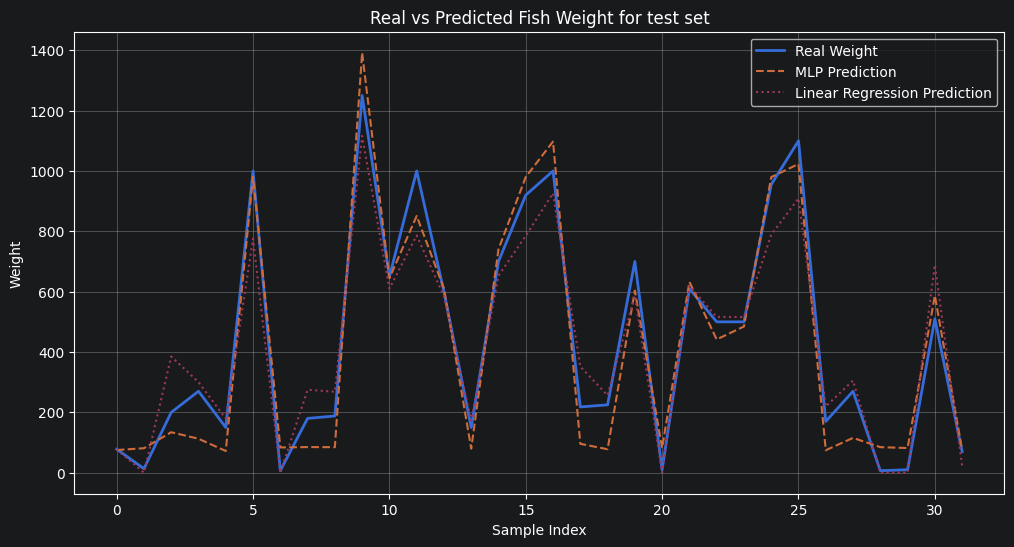

In [50]:
plt.figure(figsize=(12, 6))

# Real values
plt.plot(
    y_test.values,
    label="Real Weight",
    linewidth=2
)

# MLP predictions
plt.plot(
    y_pred_mlp,
    label="MLP Prediction",
    linestyle="--"
)

# Linear Regression predictions
plt.plot(
    y_pred_lr,
    label="Linear Regression Prediction",
    linestyle=":"
)

plt.title("Real vs Predicted Fish Weight for test set")
plt.xlabel("Fish Weight Value")
plt.xlabel("Sample Index")
plt.ylabel("Weight")

plt.legend()
plt.grid(True)

plt.show()